In [27]:
import numpy as np
import matplotlib.pyplot as plt
import math as m
import plotly.graph_objects as go
import pandas as pd
from scipy.stats import skew

## 2.1

In [28]:
U_1 = np.random.uniform(low= 0, high=1, size=10000)
U_2 = np.random.uniform(low= 0, high=1, size=10000)

Z_1 = np.sqrt(-2 * np.log(U_1)) * np.cos(2 * m.pi * U_2)
Z_2 = np.sqrt(-2 * np.log(U_1)) * np.sin(2 * m.pi * U_2)

points = [(float(Z_1[i]), float(Z_2[i])) for i in range(len(Z_1))]

print(points)
normal = np.random.normal(loc = 0, scale=1, size = 10000)

# bins = 30
# hist, xedges, yedges = np.histogram2d(Z_1, Z_2, bins=bins, density=True)

# # Construct arrays for the anchor positions of the bars
# xpos, ypos = np.meshgrid(xedges[:-1] + 0.1, yedges[:-1] + 0.1, indexing="ij")
# xpos = xpos.ravel()
# ypos = ypos.ravel()
# zpos = 0

# # Construct arrays for the dimensions of the bars
# dx = dy = 0.8 * (xedges[1] - xedges[0])
# dz = hist.ravel()

# # Plot
# fig = plt.figure(figsize=(20, 14))
# ax = fig.add_subplot(111, projection='3d')
# ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average', color='skyblue')

# ax.set_xlabel('Z1')
# ax.set_ylabel('Z2')
# ax.set_zlabel('Frequency')
# plt.show()


[(0.41379806206492514, 0.4532166784317803), (-0.865014376874659, 1.6801161682238461), (0.978460305324263, 0.42410005071859236), (-0.22742316411707592, -1.8854517869367056), (0.1040456607747508, 0.5631269474932108), (0.41503356112755974, 0.8350090870523793), (0.32431344610369417, -0.6379154302572824), (-1.2850829094862033, 1.1264033421327018), (-0.7180969755514335, 0.3015128564057696), (-0.4248265530820853, -1.5801851257940094), (0.8001782607744585, -1.501962190571036), (-0.3544394003947446, -1.0949175687883388), (1.8525224874095079, 1.192791544486011), (-1.568412559019639, -0.8506137455633537), (-0.9637283995545465, -1.4220730143341505), (0.4741658795990958, -1.2696242763082397), (1.331767629673864, 0.9358632383446515), (-0.4874153415888775, 1.9161005372878506), (-0.6274700027297021, -0.031195251938473067), (0.08094793129765504, -0.642424752104207), (0.21517318489589884, 1.3324468247247832), (-0.003979467206174786, 0.1613491852635724), (2.1499214798737665, 1.0235807282951324), (-0.1436

In [29]:
# x_centers = (xedges[:-1] + xedges[1:]) / 2
# y_centers = (yedges[:-1] + yedges[1:]) / 2
# df = pd.DataFrame(hist, index=x_centers, columns=y_centers)
# custom_color_data = df.index.values[:, None]**2 + df.columns.values[None, :]**2 + df.values**2

# # 4. Create the 3D surface plot
# fig = go.Figure(data=[go.Surface(z=df.values, x=df.index, y=df.columns, surfacecolor=custom_color_data)])

# # 5. Customize the plot
# fig.update_layout(
#     title='3D Histogram as Surface Plot',
#     scene=dict(
#         xaxis_title='Z1 Value',
#         yaxis_title='Z2 Value',
#         zaxis_title='Probability Density',
#     ),
#     autosize=True,
# )

# fig.show()

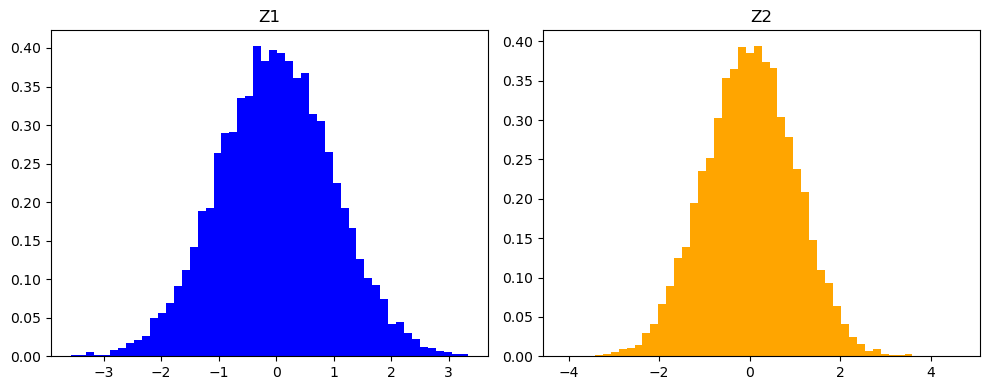

In [30]:
fig,(ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

ax1.hist(Z_1, bins=50, density=True, color='blue')
ax1.set_title("Z1")

ax2.hist(Z_2, bins=50, density=True, color='orange')
ax2.set_title("Z2")

plt.tight_layout()
plt.show()

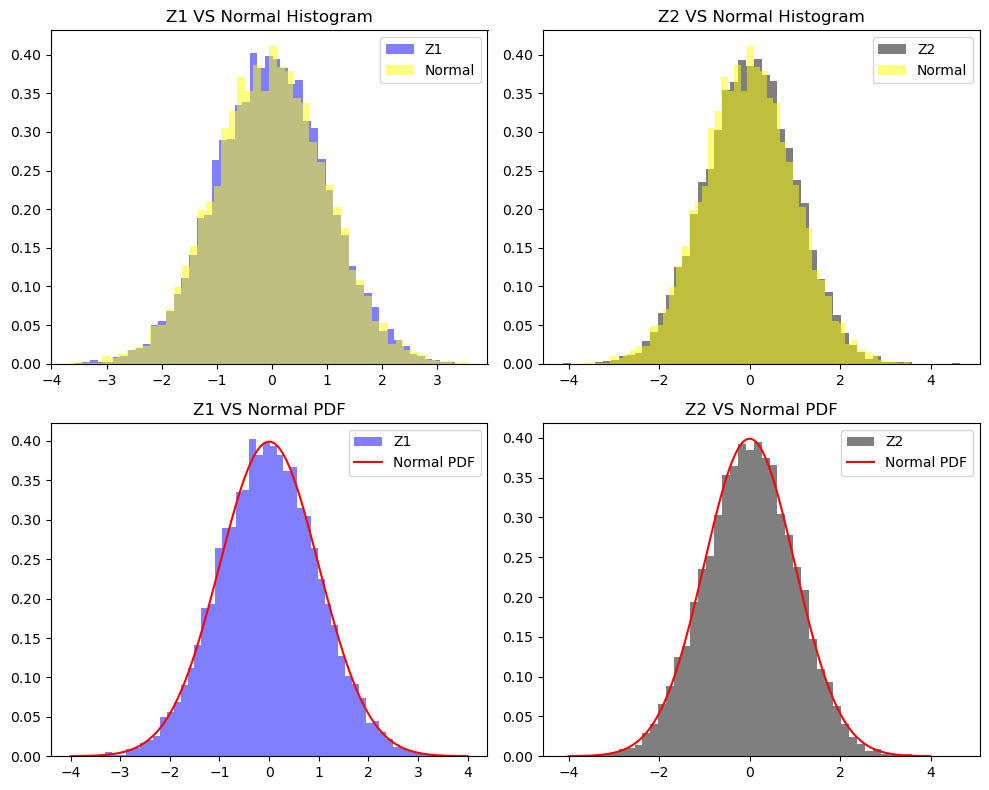

In [31]:
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,8))

ax1.hist(Z_1, bins=50, density=True, color='blue',alpha=0.5, label="Z1")
ax1.hist(normal, bins=50, density=True, color='yellow',alpha=0.5, label="Normal")
ax1.legend(loc='upper right')
ax1.set_title("Z1 VS Normal Histogram")

ax2.hist(Z_2, bins=50, density=True, color='black',alpha=0.5, label="Z2")
ax2.hist(normal, bins=50, density=True, color='yellow',alpha=0.5, label="Normal")
ax2.legend(loc='upper right')
ax2.set_title("Z2 VS Normal Histogram")


ax3.hist(Z_1, bins=50, density=True, color='blue',alpha=0.5, label="Z1")
x = np.linspace(-4,4,1000)
ax3.plot(x, (1/np.sqrt(2*m.pi)) * np.exp(-0.5 * x**2), color='red', label="Normal PDF")
ax3.legend(loc='upper right')
ax3.set_title("Z1 VS Normal PDF")

ax4.hist(Z_2, bins=50, density=True, color='black',alpha=0.5, label="Z2")
x = np.linspace(-4,4,1000)
ax4.plot(x, (1/np.sqrt(2*m.pi)) * np.exp(-0.5 * x**2), color='red', label="Normal PDF")
ax4.legend(loc='upper right')
ax4.set_title("Z2 VS Normal PDF")


plt.tight_layout()
plt.show()

In plotting $Z_1$ and $Z_2$ and comparing them to $Z$, we can see that $Z_1$ and $Z_2$ are extremely similar to $Z$. They both have a tall center, small tails, and are symetric. Overall, the histograms of all 3 are very similar. This also reflects that $Z_1$ and $Z_2$ are iid standard normal variables. Along with this, in the second set of graphs, we can see that $Z_1$ and $Z_2$ fit almost perfectly into the graph of the standard normal pdf. 

Covariance: 0.005448985245679358


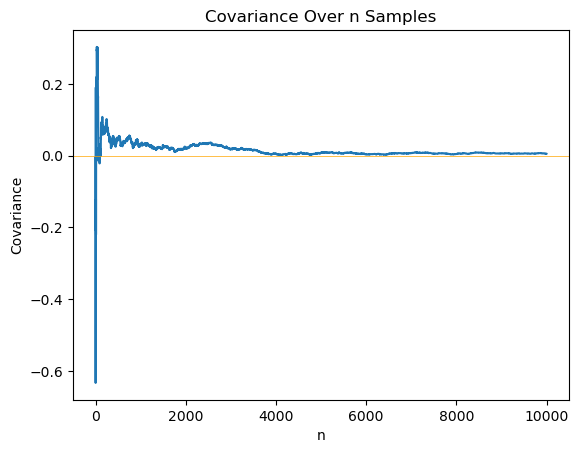

In [32]:
products = Z_1 * Z_2

cum_sum = np.cumsum(products)

covariance = cum_sum / np.arange(1,len(products) + 1)

print("Covariance:" ,covariance[-1])

plt.plot(covariance)
plt.title("Covariance Over n Samples")
plt.xlabel("n")
plt.ylabel("Covariance")
plt.axhline(0,color = 'orange', linewidth = 0.5)
plt.show()



In the above graph and printing of the covariance, we can see that the covariance for all 10000 samples is very close to 0. From the graph, we can also see that the strong law of large numbers also reflects on $E[Z_{1}Z_{2}] = 0$. As the number of samples increases, the empirical covariance converges to $0 = E[Z_{1}Z_{2}]$. This also reflects that $Z_1$ and $Z_2$ are independed standard gaussian distributions. 

## 1.3


10000
10000


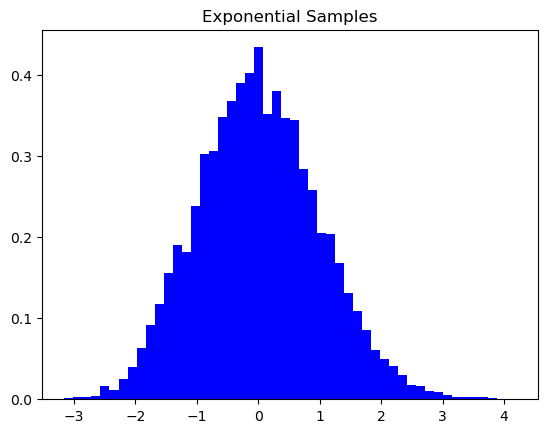

Exponential Mean: 0.008340489238924234
Exponential Median: -0.02485129592470727
Skewness: 0.1994459801811653
Mean > Median: True


In [33]:
def central_value(N = 100, size = 10000):
    lamb = 1
    std = m.sqrt(1/(lamb ** 2))
    samples = np.random.exponential(scale= 1/lamb, size=(size,N)) #the scale input is 1/lambda compared to how we define the exp dist
    sums = np.sum(samples, axis=1)
    print(len(sums))
    return (sums - (N * (1/lamb)))/ (std * m.sqrt(N))

exponential = central_value(N = 100)
print(len(exponential))
normal = np.random.normal(loc=0, scale=1, size=10000)

plt.hist(exponential, bins=50, density=True, color='blue')
plt.title("Exponential Samples")
plt.show()

print("Exponential Mean:", np.mean(exponential))
print("Exponential Median:", np.median(exponential))
print("Skewness:", skew(exponential))
print("Mean > Median:", np.mean(exponential) > np.median(exponential))



From the above graph, we can see that the distribution of $\frac{S_N - NE[X]}{\sigma \sqrt{N}}$ is close to that of a standard normal distribution. The histogram has a tall center area, and small tails that die out quickly. The reflects the central limit theorem, which says that $\frac{S_N - NE[X]}{\sigma \sqrt{N}} \xrightarrow{\text{d}} Z$ where $Z$ is the standard normal distribution. 

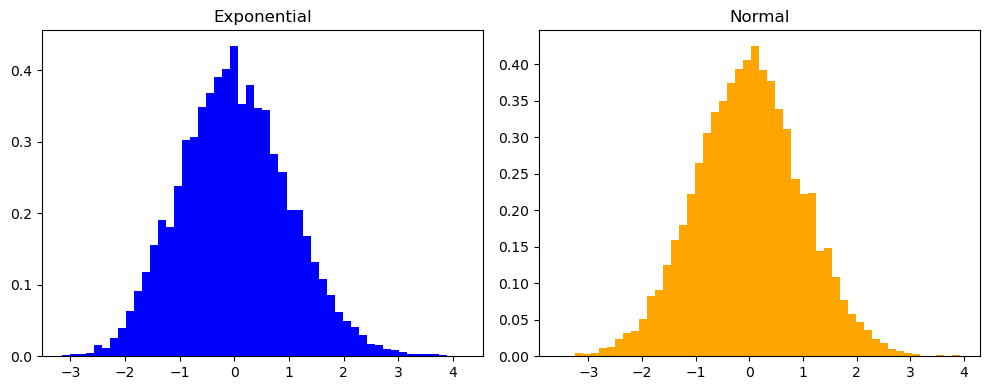

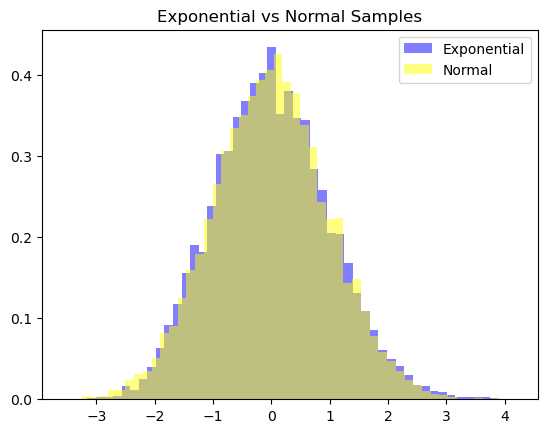

In [34]:
fig,(ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

ax1.hist(exponential, bins=50, density=True, color='blue')
ax1.set_title("Exponential")

ax2.hist(normal, bins=50, density=True, color='orange')
ax2.set_title("Normal")

plt.tight_layout()
plt.show()

plt.hist(exponential, bins=50, density=True, color='blue', alpha=0.5, label="Exponential")
plt.hist(normal, bins=50, density=True, color='yellow', alpha=0.5, label='Normal')
plt.legend(loc='upper right')
plt.title("Exponential vs Normal Samples")
plt.show()

Through putting the histograms of $ \frac{S_N - NE[X]}{\sigma \sqrt{N}}$ and $Z$ side-by-side and overtop of eachother, we can see that the two are very similar. This once again demenstrates the CLT. 

In [35]:
X_1 = np.random.normal(size=100000)
X_2 = np.random.normal(size=100000)
products = X_1 * X_2
print(np.mean(products))

0.0002748912577315675
